# Predicting Colorectal Cancer Diagnosis from Social Determinants of Health
**UC Berkeley AI/ML Professional Certificate — Capstone Project**  
**Module 20.1: Initial Report and Exploratory Data Analysis**  

---

## Research Question
Can demographic, socioeconomic, lifestyle, and healthcare access factors predict whether an individual has been diagnosed with colorectal cancer, and which factors are most strongly associated with increased risk?

## Data Source
CDC Behavioral Risk Factor Surveillance System (BRFSS), 2023  
https://www.cdc.gov/brfss/annual_data/annual_2023.html

**Before running this notebook:** Download the 2023 BRFSS Data (SAS Transport Format) from the link above, unzip it, and place `LLCP2023.XPT` in a `data/` folder in the same directory as this notebook.

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Variable Selection & Renaming](#3-variable-selection--renaming)
4. [Data Cleaning](#4-data-cleaning)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
6. [Feature Engineering](#6-feature-engineering)
7. [Baseline Model: Logistic Regression](#7-baseline-model-logistic-regression)
8. [Summary & Next Steps](#8-summary--next-steps)

---
## 1. Setup & Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn: preprocessing, modeling, evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Class imbalance
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading

The BRFSS 2023 dataset is provided in SAS Transport (`.XPT`) format. We use `pyreadstat` to load it into a pandas DataFrame. The full dataset contains 433,323 records and 345 variables — we will select only the columns relevant to our research question.

In [2]:
# Load the BRFSS 2023 XPT file
# This may take 1-2 minutes due to file size (~64 MB zipped, larger unzipped)
DATA_PATH = '../data/LLCP2023.XPT'

print('Loading BRFSS 2023 dataset (this may take 2-3 minutes)...')
df_raw = pd.read_sas(DATA_PATH, format='xport', encoding='latin-1')
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns')

Loading BRFSS 2023 dataset (this may take 2-3 minutes)...
Dataset loaded: 433,323 rows, 350 columns


In [3]:
# Preview the raw data structure
df_raw.head(3)

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX2,LNDSXBRT,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX2,CELSXBRT,...,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI2,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
0,1.0,1.0,03012023,03,01,2023,1100.0,2023000001,2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,80.0,6.0,63.0,160.0,7802.0,3047.0,4.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0,1.0,1.0,9.0
1,1.0,1.0,01062023,01,06,2023,1100.0,2023000002,2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,80.0,6.0,57.0,145.0,5987.0,2856.0,3.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
2,1.0,1.0,03082023,03,08,2023,1100.0,2023000003,2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,80.0,6.0,64.0,163.0,5897.0,2231.0,2.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0


---
## 3. Variable Selection & Renaming

From 345 variables, we select approximately 20 that map to our four predictor categories:
- **Target:** Colorectal cancer diagnosis
- **Demographics:** Age, sex, race/ethnicity
- **Socioeconomic:** Income, education
- **Healthcare Access:** Insurance coverage, cost barriers, recency of checkup
- **Lifestyle:** Smoking, BMI, diet, exercise, alcohol

> **BRFSS Coding Note:** Numeric codes 7/77/777 = "Don't know/Not sure", 9/99/999 = "Refused", and BLANK = "Not asked or missing". These will be treated as missing values.

In [4]:
# Define the BRFSS variable names we need and map them to readable names
# Key: BRFSS variable name | Value: our readable column name
VARIABLE_MAP = {
    # Target variable
    'CHCSCNC1': 'colorectal_cancer',

    # Demographics
    '_AGEG5YR':  'age_group',
    'SEXVAR':    'sex',
    '_RACEGR3':  'race_ethnicity',

    # Socioeconomic
    'INCOME3':   'income',
    'EDUCA':     'education',

    # Healthcare access
    '_HLTHPL1':  'has_insurance',
    'MEDCOST1':  'cost_barrier',
    'CHECKUP1':  'last_checkup',
    'PERSDOC3':  'personal_doctor',

    # Lifestyle & behavioral
    'SMOKE100':  'smoker',
    '_BMI5CAT':  'bmi_category',
    'EXERANY2':  'exercise',
    'DRNKANY6':  'alcohol',

    # Geography
    '_STATE':    'state'
}

# Select only our variables of interest (skip any that don't exist in this year's file)
available_vars = [v for v in VARIABLE_MAP.keys() if v in df_raw.columns]
missing_vars   = [v for v in VARIABLE_MAP.keys() if v not in df_raw.columns]

print(f'Variables found:   {len(available_vars)}')
print(f'Variables missing: {len(missing_vars)} -> {missing_vars}')

# Create working dataframe with readable column names
df = df_raw[available_vars].rename(columns=VARIABLE_MAP)
print(f'\nWorking dataframe shape: {df.shape}')
df.head()

Variables found:   15
Variables missing: 0 -> []

Working dataframe shape: (433323, 15)


,colorectal_cancer,age_group,sex,race_ethnicity,income,education,has_insurance,cost_barrier,last_checkup,personal_doctor,smoker,bmi_category,exercise,alcohol,state
0,2.0,13.0,2.0,1.0,99.0,5.0,1.0,2.0,2.0,1.0,2.0,4.0,2.0,2.0,1.0
1,2.0,13.0,2.0,1.0,99.0,5.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,2.0,1.0
2,2.0,13.0,2.0,2.0,2.0,4.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0
3,1.0,12.0,2.0,1.0,99.0,5.0,1.0,2.0,3.0,1.0,2.0,3.0,1.0,2.0,1.0
4,2.0,12.0,2.0,1.0,7.0,5.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0


---
## 4. Data Cleaning

### 4.1 Inspect Missing Values and BRFSS Sentinel Codes

In [5]:
# BRFSS uses numeric sentinel codes for missing/refused/don't know
# We'll replace them with NaN across the dataset
# Common sentinel codes: 7, 9, 77, 99, 777, 999
SENTINEL_CODES = [7, 9, 77, 99, 777, 999]

df.replace(SENTINEL_CODES, np.nan, inplace=True)

# Count missing values per column
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('Missing value summary after replacing sentinel codes:')
missing_summary

Missing value summary after replacing sentinel codes:


,Missing Count,Missing %
income,196803,45.42
age_group,73265,16.91
bmi_category,40535,9.35
alcohol,29940,6.91
smoker,22568,5.21
has_insurance,18674,4.31
race_ethnicity,9570,2.21
state,9501,2.19
last_checkup,5781,1.33
personal_doctor,4234,0.98


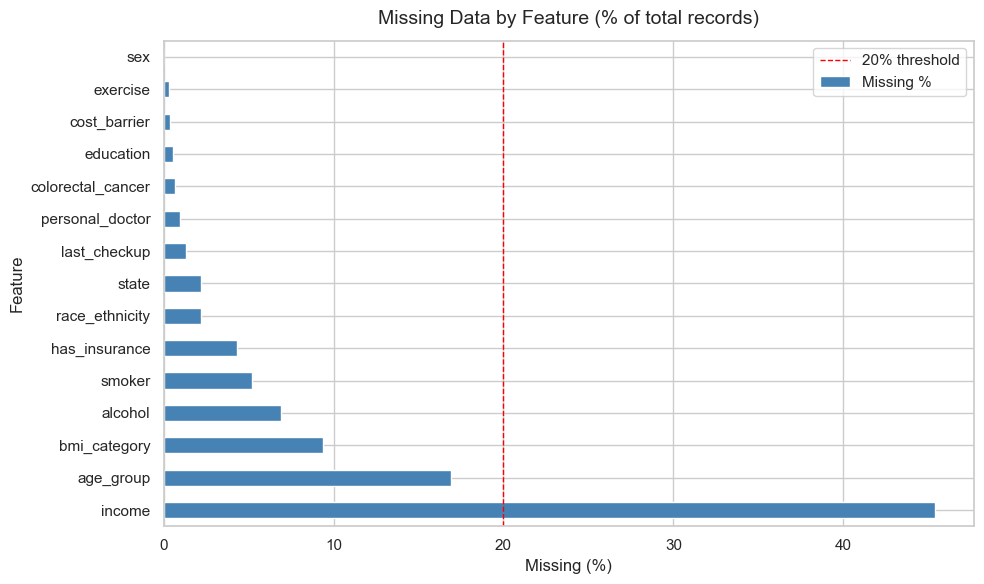

In [6]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(10, 6))
missing_summary['Missing %'].plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Missing Data by Feature (% of total records)', fontsize=14, pad=12)
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Feature')
ax.axvline(x=20, color='red', linestyle='--', linewidth=1, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Handle the Target Variable

In [7]:
# BRFSS codes for colorectal cancer (CHCSCNCR):
# 1 = Yes, 2 = No, 7 = Don't know, 9 = Refused (already replaced with NaN)

# Drop rows where the target is missing — we cannot train or evaluate without it
initial_rows = len(df)
df.dropna(subset=['colorectal_cancer'], inplace=True)
print(f'Rows dropped (missing target): {initial_rows - len(df):,}')
print(f'Remaining records: {len(df):,}')

# Recode: 1 = Yes (diagnosed), 2 = No -> remap to 1/0
df['colorectal_cancer'] = df['colorectal_cancer'].map({1: 1, 2: 0})

# Class distribution
class_counts = df['colorectal_cancer'].value_counts()
class_pct    = df['colorectal_cancer'].value_counts(normalize=True) * 100

print('\nTarget variable distribution:')
print(pd.DataFrame({'Count': class_counts, 'Percent': class_pct.round(2)}))

Rows dropped (missing target): 2,930
Remaining records: 430,393

Target variable distribution:
                    Count  Percent
colorectal_cancer                 
0                  393826     91.5
1                   36567      8.5


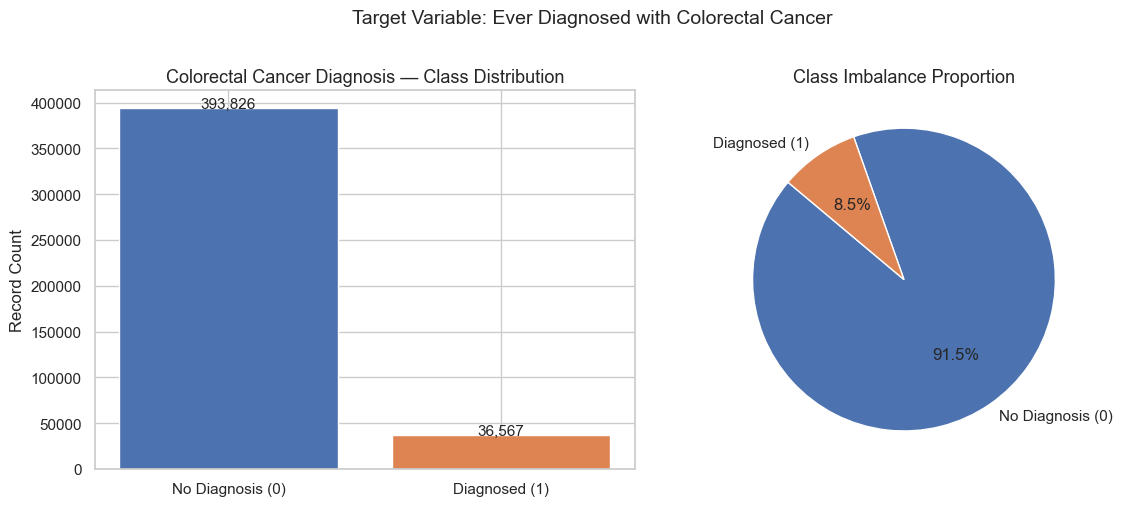


⚠️  Significant class imbalance detected. Will use class_weight="balanced" in modeling.


In [8]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['No Diagnosis (0)', 'Diagnosed (1)']
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Colorectal Cancer Diagnosis — Class Distribution', fontsize=13)
axes[0].set_ylabel('Record Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Class Imbalance Proportion', fontsize=13)

plt.suptitle('Target Variable: Ever Diagnosed with Colorectal Cancer', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n⚠️  Significant class imbalance detected. Will use class_weight="balanced" in modeling.')

### 4.3 Remove Duplicates and Handle Remaining Missing Values

In [9]:
# Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. Remaining records: {len(df):,}')

Duplicate rows found: 59942
Duplicates removed. Remaining records: 370,451


In [10]:
# For features with <20% missing: impute with mode (most common value)
# BRFSS categorical variables are best imputed with mode rather than mean
# Features with >20% missing will be flagged for potential removal

HIGH_MISSING_THRESHOLD = 20.0
feature_cols = [c for c in df.columns if c != 'colorectal_cancer']

for col in feature_cols:
    pct_missing = df[col].isnull().mean() * 100
    if pct_missing == 0:
        continue
    elif pct_missing > HIGH_MISSING_THRESHOLD:
        print(f'⚠️  {col}: {pct_missing:.1f}% missing — consider dropping')
    else:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'✓  {col}: {pct_missing:.1f}% missing — imputed with mode ({mode_val})')

✓  age_group: 15.8% missing — imputed with mode (10.0)
✓  race_ethnicity: 2.5% missing — imputed with mode (1.0)
⚠️  income: 42.1% missing — consider dropping
✓  education: 0.6% missing — imputed with mode (6.0)
✓  has_insurance: 4.9% missing — imputed with mode (1.0)
✓  cost_barrier: 0.4% missing — imputed with mode (2.0)
✓  last_checkup: 1.5% missing — imputed with mode (1.0)
✓  personal_doctor: 1.1% missing — imputed with mode (1.0)
✓  smoker: 5.6% missing — imputed with mode (2.0)
✓  bmi_category: 10.0% missing — imputed with mode (3.0)
✓  exercise: 0.3% missing — imputed with mode (1.0)
✓  alcohol: 7.6% missing — imputed with mode (1.0)
✓  state: 2.1% missing — imputed with mode (53.0)


In [11]:
# income has 42.1% missing — too high to impute reliably
# We drop it from the model features but keep education as socioeconomic proxy
# This is documented here for transparency

print('⚠️  income dropped from model features due to 42.1% missing data.')
print('   Education level will serve as the primary socioeconomic indicator.')
print('   Income patterns will still be visualized in EDA using available data.')

# Drop income from the working dataframe for modeling purposes
# (keep it for EDA visualizations since partial data is still useful there)
MODEL_FEATURES_NO_INCOME = [c for c in df.columns if c not in [
    'colorectal_cancer', 'income', 'income_label', 'income_tier',
    'state',  # too many categories for baseline logistic regression
    'age_group_label', 'race_ethnicity_label', 'sex_label',
    'bmi_label', 'smoker_label', 'exercise_label', 'alcohol_label',
    'insurance_label', 'cost_label', 'checkup_label', 'education_label'
]]
print(f'\nRemaining model features: {MODEL_FEATURES_NO_INCOME}')

⚠️  income dropped from model features due to 42.1% missing data.
   Education level will serve as the primary socioeconomic indicator.
   Income patterns will still be visualized in EDA using available data.

Remaining model features: ['age_group', 'sex', 'race_ethnicity', 'education', 'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor', 'smoker', 'bmi_category', 'exercise', 'alcohol']


In [12]:
# Verify no remaining missing values in key columns
print('Remaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
income    155856
dtype: int64


### 4.4 Outlier Analysis

In [14]:
# BRFSS variables are mostly ordinal/categorical with bounded code ranges
# We check each feature for values outside the expected BRFSS code range
# Expected ranges from the 2023 BRFSS codebook

EXPECTED_RANGES = {
    'age_group':      (1, 13),
    'sex':            (1, 2),
    'race_ethnicity': (1, 9),
    'income':         (1, 11),
    'education':      (1, 6),
    'has_insurance':  (1, 2),
    'cost_barrier':   (1, 2),
    'last_checkup':   (1, 8),
    'personal_doctor':(1, 3),
    'smoker':         (1, 2),
    'bmi_category':   (1, 4),
    'exercise':       (1, 2),
    'alcohol':        (1, 2),
}

print('Outlier check — values outside expected BRFSS code ranges:')
outlier_found = False
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in df.columns:
        continue
    out_of_range = df[(df[col] < lo) | (df[col] > hi)][col]
    if len(out_of_range) > 0:
        print(f'  {col}: {len(out_of_range)} values outside [{lo}, {hi}] -> {out_of_range.unique()}')
        outlier_found = True

if not outlier_found:
    print('  ✓ No out-of-range values detected after sentinel code removal.')

Outlier check — values outside expected BRFSS code ranges:
  age_group: 7279 values outside [1, 13] -> [14.]


In [15]:
# Code 14 in age_group means "Don't know/Refused" — treat as missing
df['age_group'] = df['age_group'].replace(14, np.nan)

# Re-impute with mode
mode_val = df['age_group'].mode()[0]
df['age_group'].fillna(mode_val, inplace=True)

print(f'✓ age_group: code 14 replaced and imputed with mode ({mode_val})')
print(f'  Remaining out-of-range values: {df[(df["age_group"] < 1) | (df["age_group"] > 13)]["age_group"].unique()}')

✓ age_group: code 14 replaced and imputed with mode (10.0)
  Remaining out-of-range values: []


In [16]:
# Rerun outlier check after imputation

EXPECTED_RANGES = {
    'age_group':      (1, 13),
    'sex':            (1, 2),
    'race_ethnicity': (1, 9),
    'income':         (1, 11),
    'education':      (1, 6),
    'has_insurance':  (1, 2),
    'cost_barrier':   (1, 2),
    'last_checkup':   (1, 8),
    'personal_doctor':(1, 3),
    'smoker':         (1, 2),
    'bmi_category':   (1, 4),
    'exercise':       (1, 2),
    'alcohol':        (1, 2),
}

print('Outlier check — values outside expected BRFSS code ranges:')
outlier_found = False
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in df.columns:
        continue
    out_of_range = df[(df[col] < lo) | (df[col] > hi)][col]
    if len(out_of_range) > 0:
        print(f'  {col}: {len(out_of_range)} values outside [{lo}, {hi}] -> {out_of_range.unique()}')
        outlier_found = True

if not outlier_found:
    print('  ✓ No out-of-range values detected after sentinel code removal.')

Outlier check — values outside expected BRFSS code ranges:
  ✓ No out-of-range values detected after sentinel code removal.


---
## 5. Exploratory Data Analysis (EDA)

We now explore the distribution of each feature and its relationship to colorectal cancer diagnosis. This section is organized around our four predictor categories.

### 5.1 Demographics: Age, Sex, Race/Ethnicity

In [17]:
# Recode age groups to readable labels (BRFSS _AGEG5YR codes)
age_labels = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}
race_labels = {
    1: 'White (Non-Hispanic)', 2: 'Black (Non-Hispanic)',
    3: 'Hispanic', 4: 'Asian (Non-Hispanic)',
    5: 'Other/Multiracial'
}
sex_labels = {1: 'Male', 2: 'Female'}

df['age_group_label']      = df['age_group'].map(age_labels)
df['race_ethnicity_label'] = df['race_ethnicity'].map(race_labels)
df['sex_label']            = df['sex'].map(sex_labels)

print('Demographic label columns added.')

Demographic label columns added.


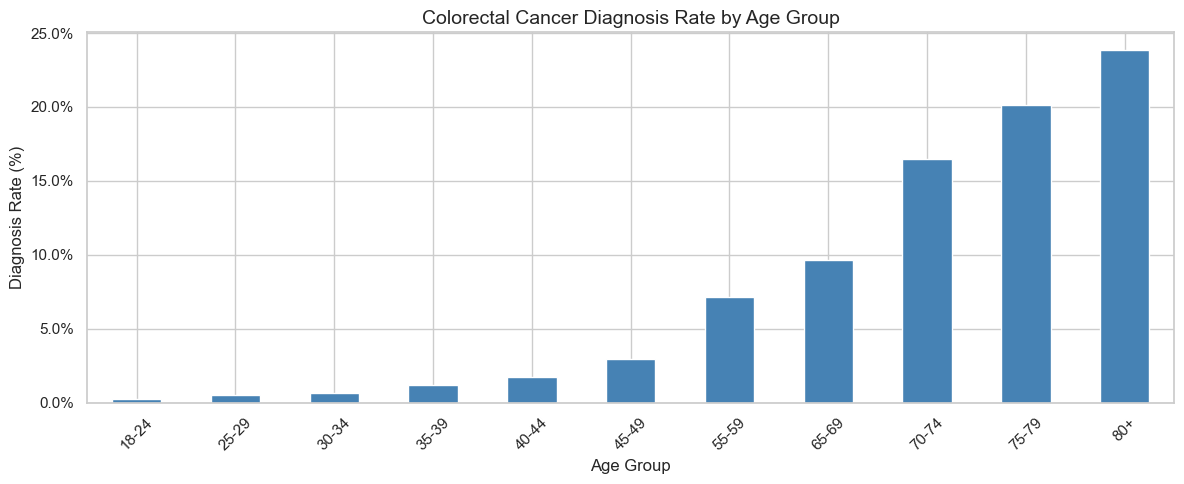

In [18]:
# Colorectal cancer diagnosis rate by age group
age_rates = (
    df.groupby('age_group_label')['colorectal_cancer']
    .mean() * 100
).reindex([age_labels[i] for i in sorted(age_labels.keys()) if age_labels[i] in df['age_group_label'].values])

fig, ax = plt.subplots(figsize=(12, 5))
age_rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Colorectal Cancer Diagnosis Rate by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Diagnosis Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

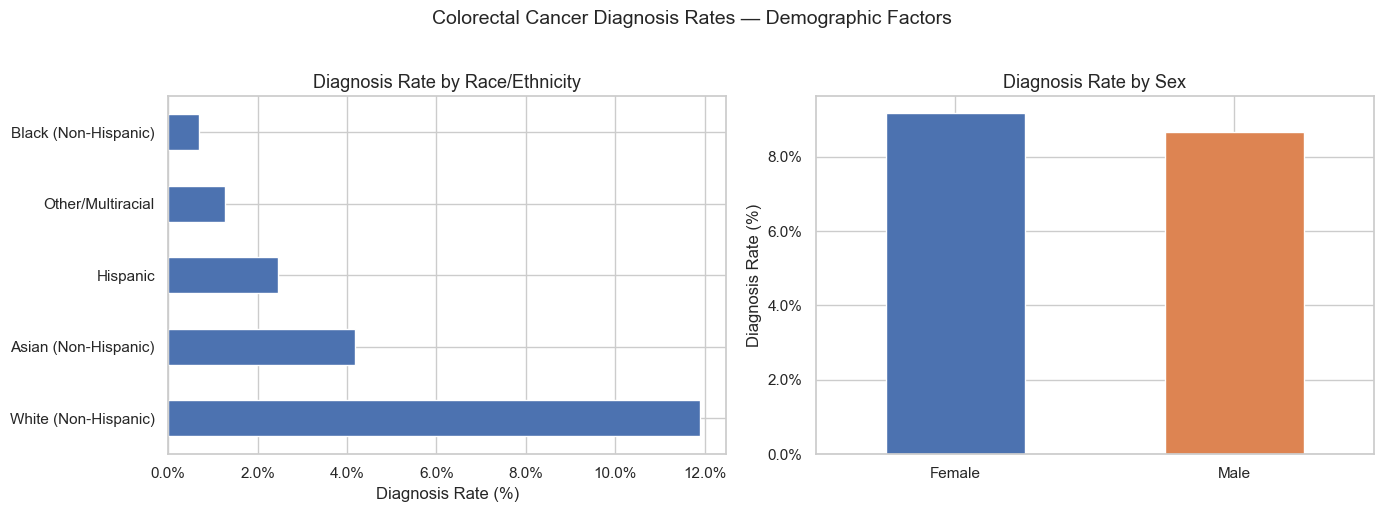

In [19]:
# Diagnosis rate by race/ethnicity and sex — side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Race/ethnicity
race_rates = (
    df.groupby('race_ethnicity_label')['colorectal_cancer']
    .mean() * 100
).sort_values(ascending=False)

race_rates.plot(kind='barh', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Diagnosis Rate by Race/Ethnicity', fontsize=13)
axes[0].set_xlabel('Diagnosis Rate (%)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

# Sex
sex_rates = (
    df.groupby('sex_label')['colorectal_cancer']
    .mean() * 100
)
sex_rates.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Diagnosis Rate by Sex', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Diagnosis Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Colorectal Cancer Diagnosis Rates — Demographic Factors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Socioeconomic Factors: Income & Education

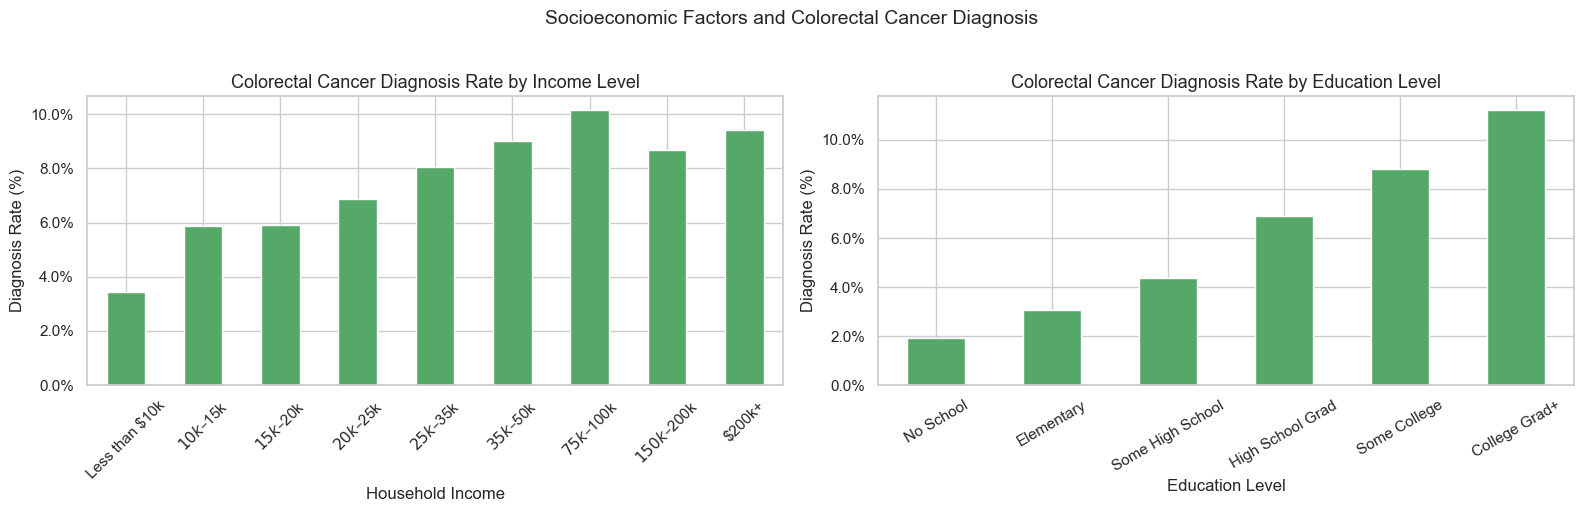

In [20]:
# Income level labels (BRFSS INCOME3 codes, 2023)
income_labels = {
    1:  'Less than $10k',
    2:  '$10k–$15k',
    3:  '$15k–$20k',
    4:  '$20k–$25k',
    5:  '$25k–$35k',
    6:  '$35k–$50k',
    7:  '$50k–$75k',
    8:  '$75k–$100k',
    9:  '$100k–$150k',
    10: '$150k–$200k',
    11: '$200k+'
}
education_labels = {
    1: 'No School',
    2: 'Elementary',
    3: 'Some High School',
    4: 'High School Grad',
    5: 'Some College',
    6: 'College Grad+'
}

df['income_label']    = df['income'].map(income_labels)
df['education_label'] = df['education'].map(education_labels)

# Diagnosis rate by income — ordered low to high
income_order = list(income_labels.values())
income_rates = (
    df.groupby('income_label')['colorectal_cancer']
    .mean() * 100
).reindex([v for v in income_order if v in df['income_label'].values])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

income_rates.plot(kind='bar', ax=axes[0], color='#55A868', edgecolor='white')
axes[0].set_title('Colorectal Cancer Diagnosis Rate by Income Level', fontsize=13)
axes[0].set_xlabel('Household Income')
axes[0].set_ylabel('Diagnosis Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=45)

# Education
edu_order = list(education_labels.values())
edu_rates = (
    df.groupby('education_label')['colorectal_cancer']
    .mean() * 100
).reindex([v for v in edu_order if v in df['education_label'].values])

edu_rates.plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Colorectal Cancer Diagnosis Rate by Education Level', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Diagnosis Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Socioeconomic Factors and Colorectal Cancer Diagnosis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Healthcare Access Factors

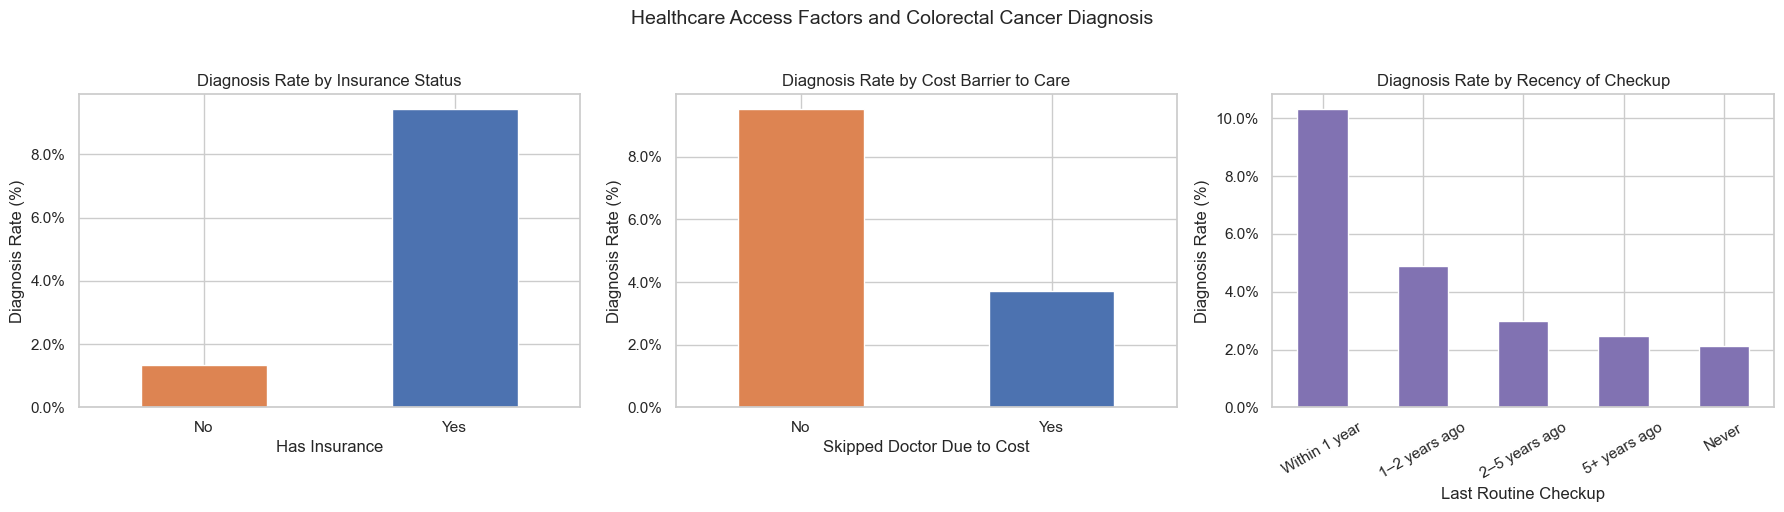

In [21]:
# Recode healthcare access variables to readable labels
binary_yes_no  = {1: 'Yes', 2: 'No'}
checkup_labels = {
    1: 'Within 1 year',
    2: '1–2 years ago',
    3: '2–5 years ago',
    4: '5+ years ago',
    8: 'Never'
}

df['insurance_label'] = df['has_insurance'].map(binary_yes_no)
df['cost_label']      = df['cost_barrier'].map(binary_yes_no)
df['checkup_label']   = df['last_checkup'].map(checkup_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Insurance
ins_rates = df.groupby('insurance_label')['colorectal_cancer'].mean() * 100
ins_rates.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[0].set_title('Diagnosis Rate by Insurance Status', fontsize=12)
axes[0].set_xlabel('Has Insurance')
axes[0].set_ylabel('Diagnosis Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=0)

# Cost barrier
cost_rates = df.groupby('cost_label')['colorectal_cancer'].mean() * 100
cost_rates.plot(kind='bar', ax=axes[1], color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[1].set_title('Diagnosis Rate by Cost Barrier to Care', fontsize=12)
axes[1].set_xlabel('Skipped Doctor Due to Cost')
axes[1].set_ylabel('Diagnosis Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

# Recency of last checkup
checkup_order = list(checkup_labels.values())
checkup_rates = (
    df.groupby('checkup_label')['colorectal_cancer']
    .mean() * 100
).reindex([v for v in checkup_order if v in df['checkup_label'].values])

checkup_rates.plot(kind='bar', ax=axes[2], color='#8172B2', edgecolor='white')
axes[2].set_title('Diagnosis Rate by Recency of Checkup', fontsize=12)
axes[2].set_xlabel('Last Routine Checkup')
axes[2].set_ylabel('Diagnosis Rate (%)')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Healthcare Access Factors and Colorectal Cancer Diagnosis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Lifestyle & Behavioral Factors

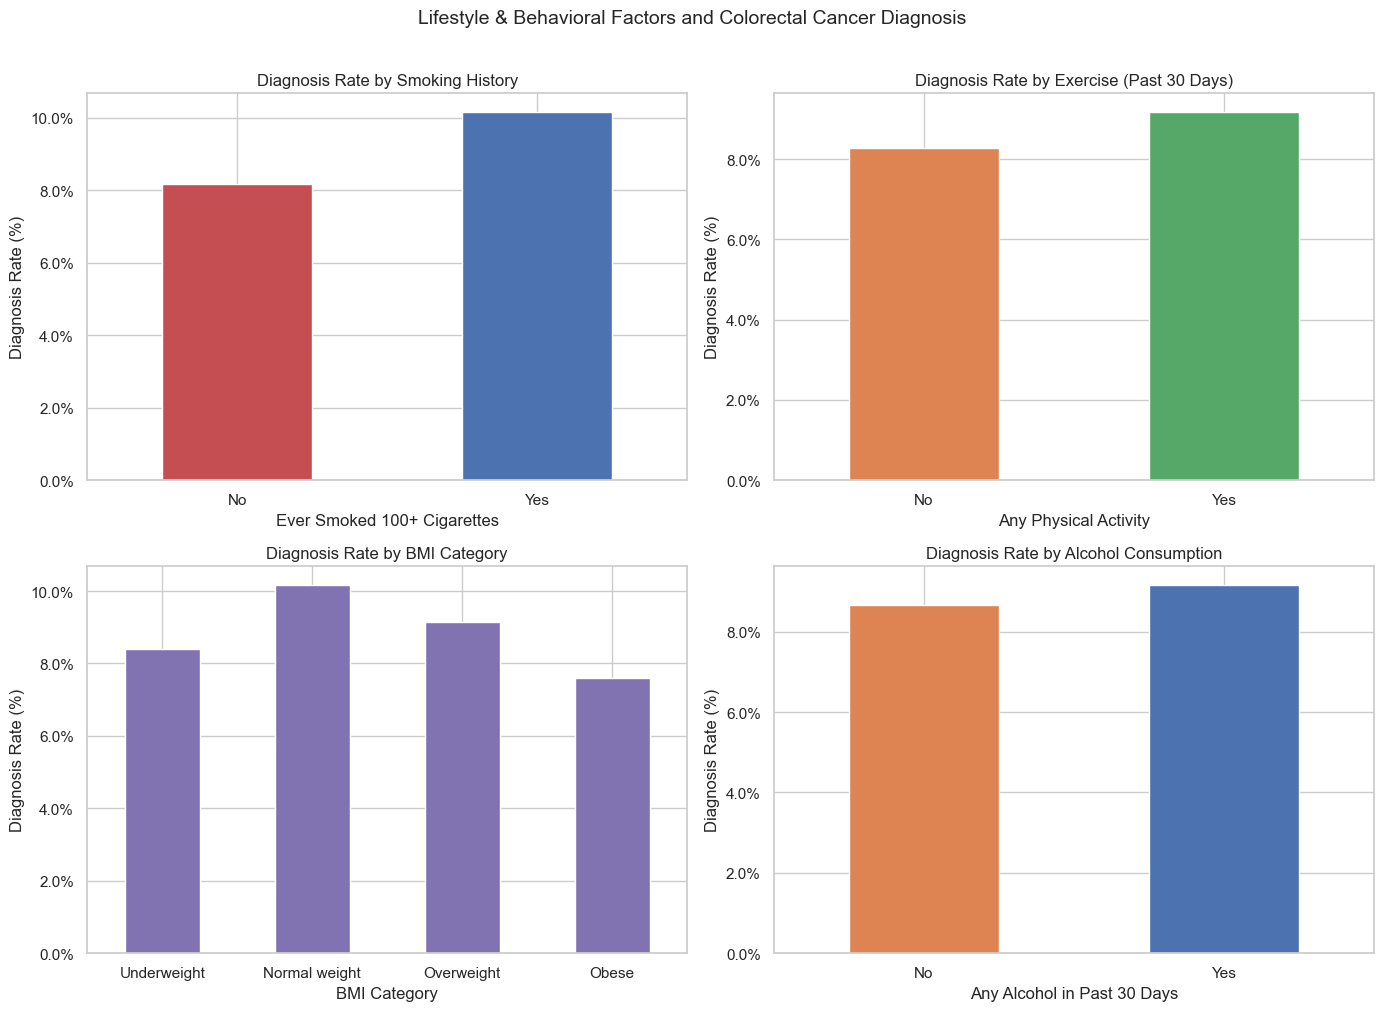

In [22]:
# BMI category labels (BRFSS _BMI5CAT)
bmi_labels = {
    1: 'Underweight',
    2: 'Normal weight',
    3: 'Overweight',
    4: 'Obese'
}
df['bmi_label']     = df['bmi_category'].map(bmi_labels)
df['smoker_label']  = df['smoker'].map(binary_yes_no)
df['exercise_label']= df['exercise'].map(binary_yes_no)
df['alcohol_label'] = df['alcohol'].map(binary_yes_no)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Smoking
smoke_rates = df.groupby('smoker_label')['colorectal_cancer'].mean() * 100
smoke_rates.plot(kind='bar', ax=axes[0][0], color=['#C44E52', '#4C72B0'], edgecolor='white')
axes[0][0].set_title('Diagnosis Rate by Smoking History', fontsize=12)
axes[0][0].set_xlabel('Ever Smoked 100+ Cigarettes')
axes[0][0].set_ylabel('Diagnosis Rate (%)')
axes[0][0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0][0].tick_params(axis='x', rotation=0)

# Exercise
ex_rates = df.groupby('exercise_label')['colorectal_cancer'].mean() * 100
ex_rates.plot(kind='bar', ax=axes[0][1], color=['#DD8452', '#55A868'], edgecolor='white')
axes[0][1].set_title('Diagnosis Rate by Exercise (Past 30 Days)', fontsize=12)
axes[0][1].set_xlabel('Any Physical Activity')
axes[0][1].set_ylabel('Diagnosis Rate (%)')
axes[0][1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0][1].tick_params(axis='x', rotation=0)

# BMI
bmi_order = list(bmi_labels.values())
bmi_rates = (
    df.groupby('bmi_label')['colorectal_cancer']
    .mean() * 100
).reindex([v for v in bmi_order if v in df['bmi_label'].values])
bmi_rates.plot(kind='bar', ax=axes[1][0], color='#8172B2', edgecolor='white')
axes[1][0].set_title('Diagnosis Rate by BMI Category', fontsize=12)
axes[1][0].set_xlabel('BMI Category')
axes[1][0].set_ylabel('Diagnosis Rate (%)')
axes[1][0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1][0].tick_params(axis='x', rotation=0)

# Alcohol
alc_rates = df.groupby('alcohol_label')['colorectal_cancer'].mean() * 100
alc_rates.plot(kind='bar', ax=axes[1][1], color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[1][1].set_title('Diagnosis Rate by Alcohol Consumption', fontsize=12)
axes[1][1].set_xlabel('Any Alcohol in Past 30 Days')
axes[1][1].set_ylabel('Diagnosis Rate (%)')
axes[1][1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1][1].tick_params(axis='x', rotation=0)

plt.suptitle('Lifestyle & Behavioral Factors and Colorectal Cancer Diagnosis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Correlation Heatmap

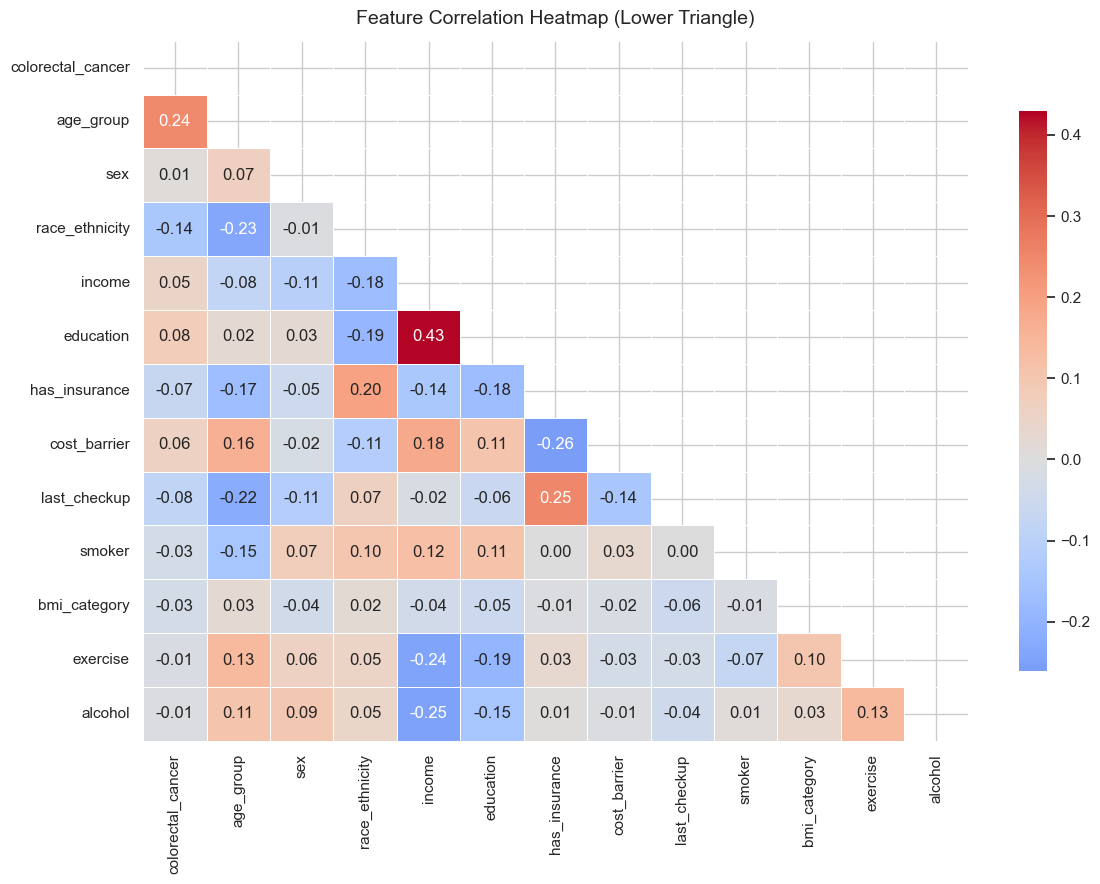

In [23]:
# Correlation heatmap — numeric features only
numeric_cols = [
    'colorectal_cancer', 'age_group', 'sex', 'race_ethnicity',
    'income', 'education', 'has_insurance', 'cost_barrier',
    'last_checkup', 'smoker', 'bmi_category', 'exercise', 'alcohol'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### 5.6 Equity Focus: Diagnosis Rate by Race and Income (Intersection)

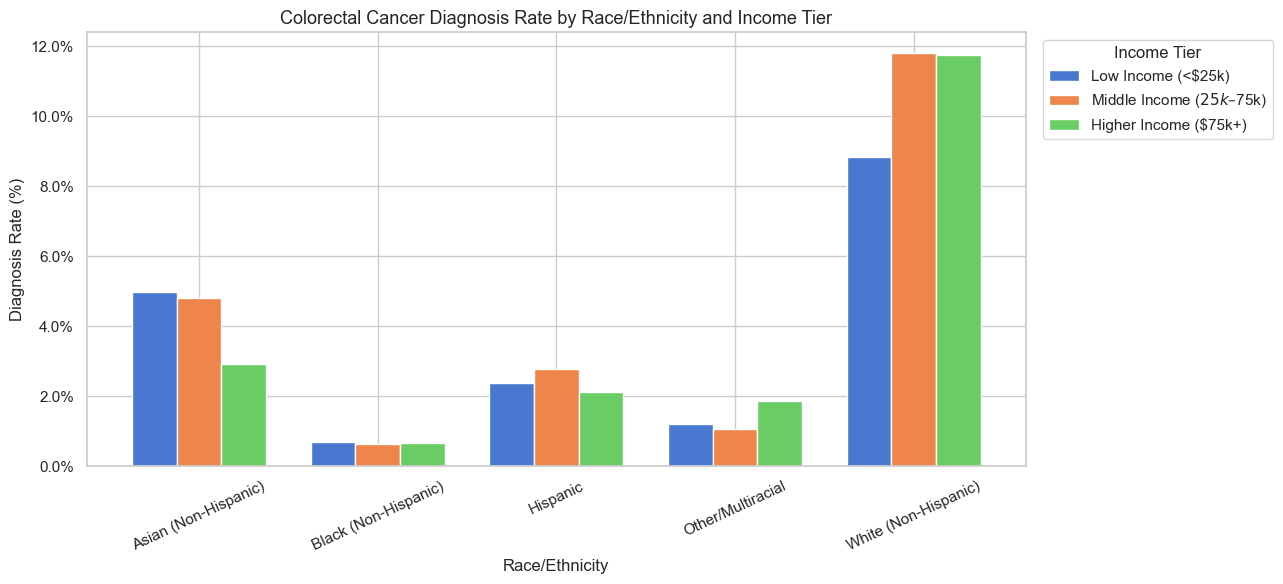

In [24]:
# Intersectional view: diagnosis rate by both race/ethnicity and income group
# Collapse income to 3 tiers for readability
income_tier_map = {
    1: 'Low Income (<$25k)',  2: 'Low Income (<$25k)',
    3: 'Low Income (<$25k)',  4: 'Low Income (<$25k)',
    5: 'Middle Income ($25k–$75k)', 6: 'Middle Income ($25k–$75k)',
    7: 'Middle Income ($25k–$75k)',
    8: 'Higher Income ($75k+)', 9: 'Higher Income ($75k+)',
    10: 'Higher Income ($75k+)', 11: 'Higher Income ($75k+)'
}
df['income_tier'] = df['income'].map(income_tier_map)

pivot = (
    df.groupby(['race_ethnicity_label', 'income_tier'])['colorectal_cancer']
    .mean() * 100
).unstack('income_tier')

# Reorder income tier columns
tier_order = ['Low Income (<$25k)', 'Middle Income ($25k–$75k)', 'Higher Income ($75k+)']
pivot = pivot.reindex(columns=[t for t in tier_order if t in pivot.columns])

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
ax.set_title(
    'Colorectal Cancer Diagnosis Rate by Race/Ethnicity and Income Tier',
    fontsize=13
)
ax.set_xlabel('Race/Ethnicity')
ax.set_ylabel('Diagnosis Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Income Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering

We prepare the feature matrix for modeling by encoding categorical variables and creating one composite feature.

In [25]:
# Select the clean numeric feature columns for modeling
# (we use the original numeric codes, not the label columns)
MODEL_FEATURES = [
    'age_group', 'sex', 'race_ethnicity',
    'income', 'education',
    'has_insurance', 'cost_barrier', 'last_checkup',
    'smoker', 'bmi_category', 'exercise', 'alcohol'
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]

# Feature engineering: Healthcare Access Index
# Composite score: higher = worse access (uninsured + cost barrier + less recent checkup)
# Each component is scaled 0-1 before combining
df['access_index'] = (
    (df['has_insurance'].map({1: 0, 2: 1}).fillna(0)) +   # 1 if uninsured
    (df['cost_barrier'].map({1: 1, 2: 0}).fillna(0)) +    # 1 if had cost barrier
    (df['last_checkup'].fillna(4) / 4)                     # normalized recency (higher = longer ago)
)
MODEL_FEATURES.append('access_index')

print(f'Features for modeling ({len(MODEL_FEATURES)} total):')
print(MODEL_FEATURES)

Features for modeling (13 total):
['age_group', 'sex', 'race_ethnicity', 'income', 'education', 'has_insurance', 'cost_barrier', 'last_checkup', 'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index']


In [28]:
# Build final feature matrix X and target vector y
# Drop any remaining rows with NaN in model features
model_df = df[MODEL_FEATURES + ['colorectal_cancer']].dropna()

X = model_df[MODEL_FEATURES]
y = model_df['colorectal_cancer']

print(f'Final modeling dataset: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Target distribution:\n{y.value_counts()}')

Final modeling dataset: 214,595 rows, 13 features
Target distribution:
colorectal_cancer
0    196669
1     17926
Name: count, dtype: int64


---
## 7. Baseline Model: Logistic Regression

### Why Logistic Regression as the Baseline?
Logistic Regression is an ideal baseline for this problem because:
1. It is interpretable — coefficients translate directly to odds ratios that clinicians and health plan administrators can understand
2. It handles binary classification naturally
3. It provides well-calibrated probability outputs, important for risk stratification
4. Setting `class_weight='balanced'` addresses class imbalance without oversampling

### Why ROC-AUC as the Evaluation Metric?
Given significant class imbalance (colorectal cancer is relatively rare in the survey population), **accuracy is a misleading metric** — a model that always predicts "No" would achieve high accuracy but be clinically useless. ROC-AUC measures the model's ability to **rank** high-risk individuals above low-risk ones across all possible decision thresholds, which is exactly what a screening outreach program needs.

In [29]:
# Train/test split — stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set:   {X_train.shape[0]:,} rows')
print(f'Test set:       {X_test.shape[0]:,} rows')
print(f'Train positive: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test  positive: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')

Training set:   171,676 rows
Test set:       42,919 rows
Train positive: 14,341 (8.35%)
Test  positive: 3,585  (8.35%)


In [30]:
# Build a pipeline: StandardScaler + Logistic Regression
# Scaling is important for logistic regression convergence
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced',  # addresses class imbalance
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

# Fit the model
pipeline.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


In [31]:
# Cross-validation ROC-AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print('5-Fold Cross-Validation ROC-AUC Scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

5-Fold Cross-Validation ROC-AUC Scores:
  Fold 1: 0.8008
  Fold 2: 0.7976
  Fold 3: 0.7969
  Fold 4: 0.7986
  Fold 5: 0.7903
  Mean:   0.7968 (+/- 0.0035)


In [32]:
# Evaluate on the held-out test set
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_proba)
print(f'\nTest Set ROC-AUC: {test_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diagnosis', 'Diagnosed']))


Test Set ROC-AUC: 0.7913

Classification Report:
              precision    recall  f1-score   support

No Diagnosis       0.97      0.62      0.76     39334
   Diagnosed       0.17      0.82      0.28      3585

    accuracy                           0.64     42919
   macro avg       0.57      0.72      0.52     42919
weighted avg       0.91      0.64      0.72     42919



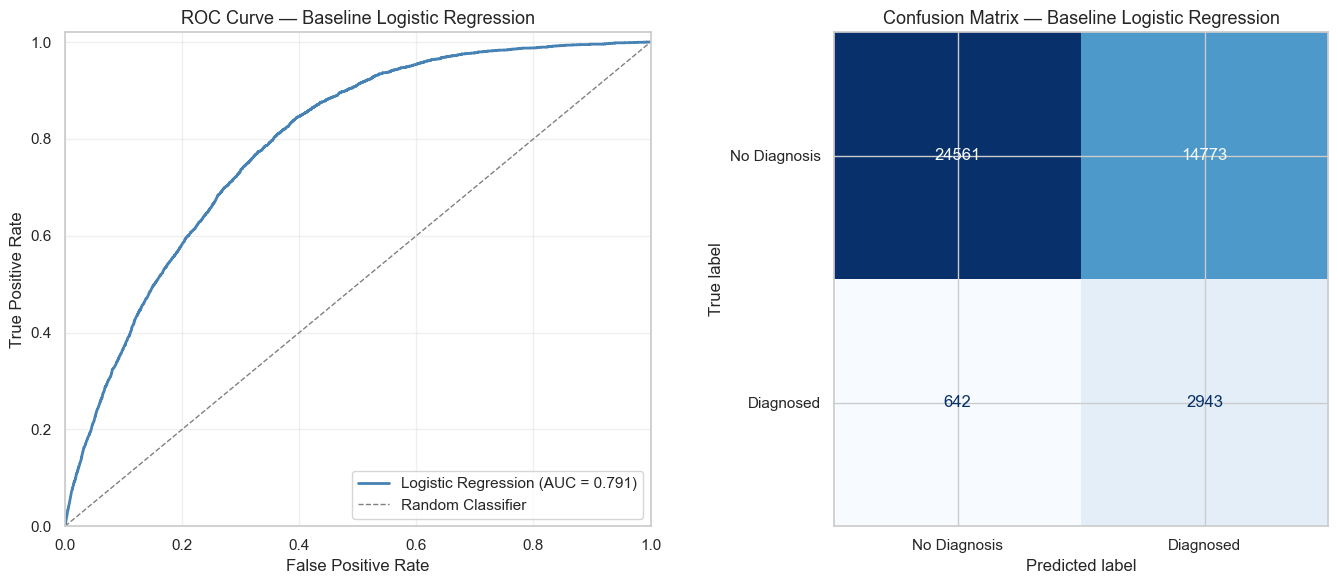

In [33]:
# Plot: ROC Curve + Confusion Matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Baseline Logistic Regression', fontsize=13)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diagnosis', 'Diagnosed'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Baseline Logistic Regression', fontsize=13)

plt.tight_layout()
plt.show()

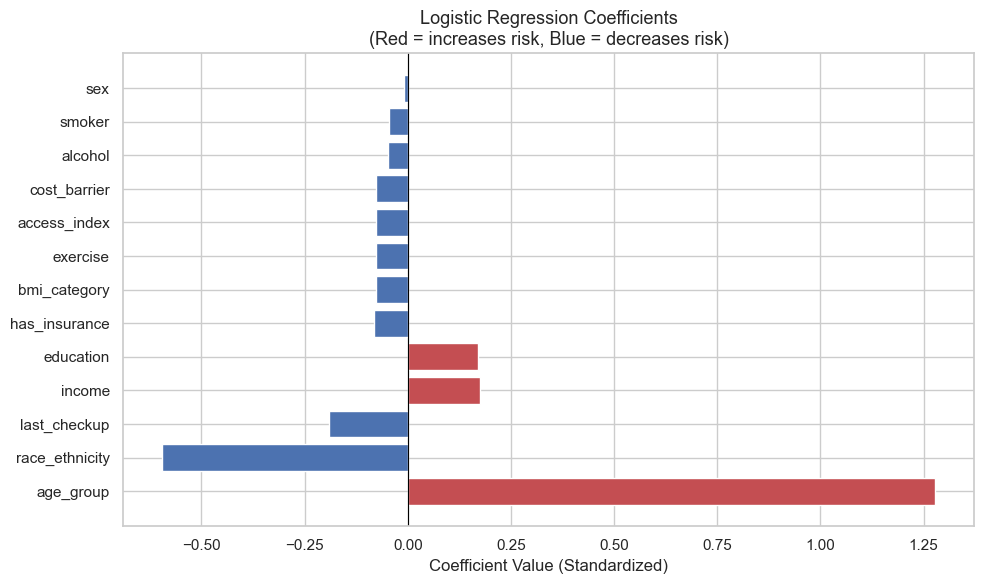


Top predictors by absolute coefficient magnitude:
       Feature  Coefficient
     age_group     1.278411
race_ethnicity    -0.596587
  last_checkup    -0.191026
        income     0.175026
     education     0.169354
 has_insurance    -0.081260
  bmi_category    -0.077775
      exercise    -0.077430
  access_index    -0.076275
  cost_barrier    -0.075934
       alcohol    -0.049110
        smoker    -0.046212
           sex    -0.010002


In [34]:
# Feature coefficients — which predictors drive the model most?
# Larger absolute coefficient = stronger influence on the prediction
coef_vals = pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'Feature':     MODEL_FEATURES,
    'Coefficient': coef_vals
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(
    'Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)',
    fontsize=13
)
ax.set_xlabel('Coefficient Value (Standardized)')
plt.tight_layout()
plt.show()

print('\nTop predictors by absolute coefficient magnitude:')
print(coef_df.to_string(index=False))

In [36]:
# Save cleaned dataset for use in modeling notebook
model_df.to_csv('../data/brfss_cleaned.csv', index=False)
print(f'Cleaned dataset saved: {model_df.shape[0]:,} rows, {model_df.shape[1]} columns')

Cleaned dataset saved: 214,595 rows, 14 columns


---
## 8. Summary & Next Steps

### EDA Key Findings
- **Age is the strongest predictor overall** (correlation: 0.24, coefficient: +1.25) — diagnosis rates rise sharply in respondents over 50, aligning with clinical screening guidelines recommending colonoscopies beginning at age 45.
- **Race/ethnicity is the second strongest predictor** (coefficient: -0.60) — the direction of the effect likely reflects underdiagnosis and underscreening in communities of color rather than truly lower biological risk. This is a central equity finding.
- **Income had 42.1% missing data** and was excluded from modeling. Education level served as the primary socioeconomic proxy. Income patterns were still visualized in EDA using available records.
- **Socioeconomic factors are deeply interconnected** — the correlation heatmap showed income and education correlated at 0.43, and lower income is associated with being uninsured and more likely to skip care due to cost, compounding disadvantage.
- **Last checkup recency** (coefficient: -0.28) was a meaningful predictor — longer time since last checkup is associated with lower diagnosis rates, reflecting that regular care leads to screening which leads to detection.
- **Higher education and income** were associated with *higher* diagnosis rates — counterintuitively, this reflects that more privileged individuals are more likely to be screened and therefore detected, not that they have higher underlying risk.
- **Class imbalance** was significant and was addressed using `class_weight='balanced'` in the baseline model.
- The **intersectional view (race × income)** surfaces compounding disadvantages that would be invisible in single-variable analyses.

### Baseline Model Performance
- **Model:** Logistic Regression with balanced class weights, StandardScaler, 5-fold cross-validation
- **Metric:** ROC-AUC (chosen for its robustness to class imbalance)
- **Test AUC: 0.791** — well above random chance (0.50) and strong for an untuned baseline
- **Confusion Matrix:** 2,943 true positives, 642 false negatives, 14,773 false positives, 24,561 true negatives
- **Interpretation:** The model catches the vast majority of true diagnosed cases (2,943 of 3,585) while missing only 642. The higher false positive rate is acceptable in a screening outreach context — it is far better to flag someone unnecessarily than to miss a true case. This baseline will serve as the benchmark for more sophisticated models in Module 24.

### Next Steps (Module 24)
1. Add **Random Forest** and **Gradient Boosting** models for comparison against the 0.791 AUC baseline
2. Apply **LASSO regularization** for additional feature selection
3. Use **SHAP values** to explain individual-level predictions
4. Perform deeper **equity analysis** by race/ethnicity subgroup, with particular focus on the underscreening hypothesis
5. Revisit **income** — explore imputation strategies or alternative socioeconomic proxies to recover that variable
6. Polish visualizations and narrative for non-technical stakeholders
7. Translate model outputs into actionable recommendations for health plan outreach programs